In [4]:
import numpy as np

X_train_vec = np.load('../data/processed/X_train_vec.npy')
X_val_vec   = np.load('../data/processed/X_val_vec.npy')
X_test_vec  = np.load('../data/processed/X_test_vec.npy')
y_train     = np.load('../data/processed/y_train.npy')
y_val       = np.load('../data/processed/y_val.npy')
y_test      = np.load('../data/processed/y_test.npy')

print("✅ Đã nạp dữ liệu thành công!")
print(f"   Train: {X_train_vec.shape} | Val: {X_val_vec.shape} | Test: {X_test_vec.shape}")

✅ Đã nạp dữ liệu thành công!
   Train: (402542, 500) | Val: (86259, 500) | Test: (86260, 500)


In [5]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train_vec, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_vec,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=256)

In [6]:
class AnomalyMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze()

model = AnomalyMLP(input_dim=500)

pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"pos_weight = {pos_weight_value:.2f}")

pos_weight = 33.15


In [7]:
import os, matplotlib.pyplot as plt

epochs   = 50
patience = 8
best_val_loss    = float('inf')
epochs_no_improve = 0

# ── Khởi tạo history ──────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

def calc_accuracy(loader, model):
    """Tính accuracy trên toàn bộ loader (không tính gradient)."""
    correct = total = 0
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            preds = (torch.sigmoid(model(xb)) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total   += len(yb)
    return correct / total

print('🚀 Bắt đầu huấn luyện...')
for epoch in range(epochs):

    # ── Train ────────────────────────────────────────────────
    model.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # ── Validation ───────────────────────────────────────────
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            total_val_loss += criterion(model(xb), yb).item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss   = total_val_loss   / len(val_loader)
    train_acc      = calc_accuracy(train_loader, model)
    val_acc        = calc_accuracy(val_loader,   model)

    # ── Ghi history ──────────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {avg_train_loss:.4f}  Val Loss: {avg_val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}")

    # ── Early Stopping ───────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss     = avg_val_loss
        epochs_no_improve = 0
        os.makedirs('../models', exist_ok=True)
        torch.save(model.state_dict(), '../models/best_model.pth')
        print(f"  💾 Đã lưu best model (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"⚠️  Early Stopping tại Epoch {epoch+1}!")
            break

print('\n✅ Huấn luyện xong!')

🚀 Bắt đầu huấn luyện...
Epoch 01 | Train Loss: 0.3496  Val Loss: 0.2050 | Train Acc: 0.9798  Val Acc: 0.9793
  💾 Đã lưu best model (val_loss=0.2050)
Epoch 02 | Train Loss: 0.1184  Val Loss: 0.0786 | Train Acc: 0.9960  Val Acc: 0.9957
  💾 Đã lưu best model (val_loss=0.0786)
Epoch 03 | Train Loss: 0.0394  Val Loss: 0.0537 | Train Acc: 0.9964  Val Acc: 0.9962
  💾 Đã lưu best model (val_loss=0.0537)
Epoch 04 | Train Loss: 0.0212  Val Loss: 0.0256 | Train Acc: 0.9970  Val Acc: 0.9969
  💾 Đã lưu best model (val_loss=0.0256)
Epoch 05 | Train Loss: 0.0167  Val Loss: 0.0241 | Train Acc: 0.9979  Val Acc: 0.9978
  💾 Đã lưu best model (val_loss=0.0241)
Epoch 06 | Train Loss: 0.0129  Val Loss: 0.0155 | Train Acc: 0.9971  Val Acc: 0.9971
  💾 Đã lưu best model (val_loss=0.0155)
Epoch 07 | Train Loss: 0.0154  Val Loss: 0.0239 | Train Acc: 0.9982  Val Acc: 0.9981
Epoch 08 | Train Loss: 0.0147  Val Loss: 0.0337 | Train Acc: 0.9991  Val Acc: 0.9987
Epoch 09 | Train Loss: 0.0138  Val Loss: 0.0134 | Train 

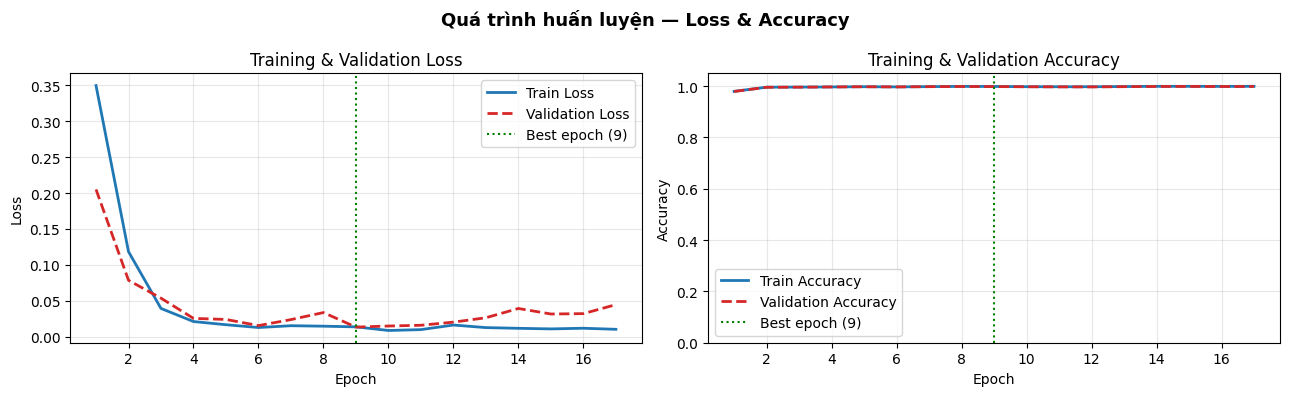

✅ Biểu đồ lưu tại: outputs/training_history.png
   Best epoch: 9  |  Best val_loss: 0.0134


In [8]:
# ── Vẽ 2 đường Loss & Accuracy ─────────────────────────────────────────────────
epochs_ran = len(history['train_loss'])
x_axis     = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Quá trình huấn luyện — Loss & Accuracy', fontsize=13, fontweight='bold')

# --- Loss ---
ax1.plot(x_axis, history['train_loss'], label='Train Loss',      color='#1f77b4', lw=2)
ax1.plot(x_axis, history['val_loss'],   label='Validation Loss', color='#d62728', lw=2, linestyle='--')

best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
ax1.axvline(x=best_epoch, color='green', linestyle=':', lw=1.5,
            label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy ---
ax2.plot(x_axis, history['train_acc'], label='Train Accuracy',      color='#1f77b4', lw=2)
ax2.plot(x_axis, history['val_acc'],   label='Validation Accuracy', color='#d62728', lw=2, linestyle='--')
ax2.axvline(x=best_epoch, color='green', linestyle=':', lw=1.5,
            label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Biểu đồ lưu tại: outputs/training_history.png')
print(f'   Best epoch: {best_epoch}  |  Best val_loss: {min(history["val_loss"]):.4f}')